# Superposition-$g$ latent FTNODE vs unstructured latent NODE (partial Duffing obs)

Sibling of the consistency study, with the L-FT equilibrium map replaced by a
**restrained superposition of learnable anchors** (see §2b). Three models over 10
seeds on a fixed dataset: **L-N** (plain latent NODE), **L-FT** (superposition-$g$),
**L-FT+res** (superposition-$g$ + residual penalty). Both FT models are
`LatentFTNODESuper` and differ only in `lam_res`. `ALPHA_FORM` selects the coefficient
squashing — set it from the alpha-screen pilot notebook.

In [1]:
import sys, pathlib, time
ROOT = pathlib.Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as Fnn


In [2]:
# ---- experiment configuration (superposition-g) --------------------------------
# SMOKE=True gives a fast end-to-end check (tiny data / few epochs / few seeds).
SMOKE = False

ELL        = 8            # number of learnable anchor vectors g_i (over-specified vs m=4)
ALPHA_FORM = 'sparsemax'  # 'sparsemax' | 'softmax' | 'sigmoid_l1'  -- set from the alpha-screen pilot
LAM_ALPHA  = 1e-3         # light, always-on alpha-sparsity weight on the FT-super models
LAM_RES    = 1e-2         # residual penalty weight for the '+res' variant
print(f'SMOKE={SMOKE}  ELL={ELL}  ALPHA_FORM={ALPHA_FORM}  LAM_ALPHA={LAM_ALPHA}  LAM_RES={LAM_RES}')


SMOKE=False  ELL=8  ALPHA_FORM=sparsemax  LAM_ALPHA=0.001  LAM_RES=0.01


## Duffing plant

In [3]:
from __future__ import annotations

from dataclasses import dataclass

import numpy as np


@dataclass(frozen=True)
class DuffingParams:
    delta: float = 0.2  # damping; small enough that approach is underdamped


def F(x: np.ndarray, u: float | np.ndarray, params: DuffingParams) -> np.ndarray:
    """Plant vector field. x has shape (..., 2); u is scalar (or shape (...,))."""
    x1 = x[..., 0]
    x2 = x[..., 1]
    f1 = x2
    f2 = -params.delta * x2 - x1**3 + x1 + np.asarray(u)
    return np.stack([f1, f2], axis=-1)


def DxF(x: np.ndarray, u: float, params: DuffingParams) -> np.ndarray:
    """Jacobian D_x F at a single state x of shape (2,)."""
    x1 = x[..., 0]
    return np.array(
        [
            [0.0, 1.0],
            [1.0 - 3.0 * x1**2, -params.delta],
        ]
    )


def DuF(x: np.ndarray, u: float, params: DuffingParams) -> np.ndarray:
    """Jacobian D_u F at state x. Returns shape (2,)."""
    return np.array([0.0, 1.0])


def equilibria(u: float) -> list[np.ndarray]:
    """Equilibria of the autonomous Duffing system at fixed u.

    Solve x1**3 - x1 - u = 0 (with x2 = 0). Returns the real roots as
    states (x1, 0). For |u| < 2/(3*sqrt(3)) ~= 0.385 there are three roots:
    two sinks (outer roots) and one saddle (middle root). Sink labelled by
    sign of x1.
    """
    coeffs = [1.0, 0.0, -1.0, -float(u)]
    roots = np.roots(coeffs)
    real_roots = sorted(r.real for r in roots if abs(r.imag) < 1e-9)
    return [np.array([r, 0.0]) for r in real_roots]


def sinks(u: float) -> dict[str, np.ndarray]:
    """Return the two hyperbolic sinks (left/right) when bistable.

    Falls back to a single sink when u is outside the bistable window.
    """
    eqs = equilibria(u)
    if len(eqs) == 3:
        return {"left": eqs[0], "right": eqs[2]}
    return {"only": eqs[0]}


def simulate(
    x0: np.ndarray,
    u_of_t,
    params: DuffingParams,
    t_grid: np.ndarray,
) -> np.ndarray:
    """Integrate the plant on t_grid with control u_of_t (callable t -> u).

    Uses RK4 with the t_grid spacing. Returns array of shape (T, 2).
    """
    xs = np.empty((len(t_grid), 2))
    xs[0] = x0
    for i in range(len(t_grid) - 1):
        t = t_grid[i]
        h = t_grid[i + 1] - t
        x = xs[i]
        u1 = u_of_t(t)
        u2 = u_of_t(t + 0.5 * h)
        u4 = u_of_t(t + h)
        k1 = F(x, u1, params)
        k2 = F(x + 0.5 * h * k1, u2, params)
        k3 = F(x + 0.5 * h * k2, u2, params)
        k4 = F(x + h * k3, u4, params)
        xs[i + 1] = x + (h / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
    return xs

In [4]:
torch.manual_seed(0)
np.random.seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

params = DuffingParams(delta=0.2)
print('open-loop sinks at u=0:', sinks(0.0))

device: cpu
open-loop sinks at u=0: {'left': array([-1.,  0.]), 'right': array([1., 0.])}


## 1. Generate partial-observation data (fixed across all seeds)

Long rollouts of the Duffing plant under random piecewise-constant $u$. We keep the full state for
evaluation but expose only $y=q$ to training. **This dataset is generated once here and reused for
every seed and every model** — the per-seed variation in this study comes only from model init and
minibatch order, never from the data.

The training signal is `(window, u, y_long)` triples: `window` = $\tau$ samples of $y$ before $t=0$
(encoder input), `u` = the constant control, `y_long` = the next $L$ observations (target). We use a
*long* horizon ($L=200$ at $h=0.05$) so that an unstructured latent NODE is likely to blow up during
training before it fits.

train: window torch.Size([512, 8]) u torch.Size([512]) y_long torch.Size([512, 201])
val  : window torch.Size([64, 8]) u torch.Size([64]) y_long torch.Size([64, 601]) (extrapolation horizon)


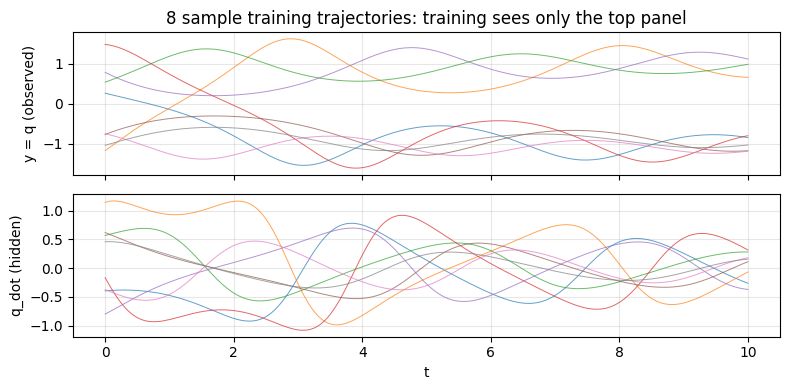

In [5]:
h_dt   = 0.05      # integration timestep
tau    = 8         # encoder window length
L      = 200       # training rollout length (T = 10)
L_eval = 600       # eval horizon (T = 30) -> tests extrapolation
u_range = 0.25
x_range = 1.6

if SMOKE:
    L, L_eval = 20, 30
    N_TRAJ_TR, N_TRAJ_VA = 32, 16
else:
    N_TRAJ_TR, N_TRAJ_VA = 512, 64

def make_dataset(n_traj=512, L=L, tau=tau, h=h_dt, seed=0):
    rng = np.random.default_rng(seed)
    # Total trajectory length: tau (warmup) + L (rollout target) + 1
    Ttot = tau + L + 1
    t_grid = np.arange(Ttot) * h
    Xfull = np.zeros((n_traj, Ttot, 2), dtype=np.float32)
    U     = np.zeros((n_traj,), dtype=np.float32)
    for i in range(n_traj):
        # Random IC anywhere reasonable (both basins, with some velocity).
        x0 = np.array([
            rng.uniform(-x_range, x_range),
            rng.uniform(-1.0, 1.0),
        ], dtype=np.float64)
        u  = float(rng.uniform(-u_range, u_range))
        traj = simulate(x0, lambda t, _u=u: _u, params, t_grid)
        Xfull[i] = traj.astype(np.float32)
        U[i] = u
    Y    = Xfull[..., 0]                 # observed: q only
    Wind = Y[:, :tau]                    # encoder window
    Yl   = Y[:, tau:tau + L + 1]         # rollout target (L+1 samples)
    Xl   = Xfull[:, tau:tau + L + 1]     # full state for evaluation
    return (
        torch.from_numpy(Wind),
        torch.from_numpy(U),
        torch.from_numpy(Yl),
        torch.from_numpy(Xl),
    )

Wtr, Utr, Ytr, Xtr = make_dataset(n_traj=N_TRAJ_TR, L=L, seed=0)
Wva, Uva, Yva, Xva = make_dataset(n_traj=N_TRAJ_VA, L=L_eval, seed=1)
print('train: window', Wtr.shape, 'u', Utr.shape, 'y_long', Ytr.shape)
print('val  : window', Wva.shape, 'u', Uva.shape, 'y_long', Yva.shape, '(extrapolation horizon)')

fig, axes = plt.subplots(2, 1, figsize=(8, 4), sharex=True)
tline = np.arange(L + 1) * h_dt
for i in range(8):
    axes[0].plot(tline, Ytr[i].numpy(), lw=0.7, alpha=0.7)
    axes[1].plot(tline, Xtr[i, :, 1].numpy(), lw=0.7, alpha=0.7)
axes[0].set_ylabel('y = q (observed)'); axes[0].grid(alpha=0.3)
axes[1].set_ylabel('q_dot (hidden)'); axes[1].set_xlabel('t'); axes[1].grid(alpha=0.3)
axes[0].set_title('8 sample training trajectories: training sees only the top panel')
plt.tight_layout(); plt.show()

## 2. Latent state-space models

All three models share the encoder/decoder; only the latent dynamics differ.

- **Encoder** `phi(window) -> z0`: small MLP $\R^\tau\to\R^m$ with a `tanh` head scaled by $R_z$ so
  $\boldsymbol{z}_0\in[-R_z,R_z]^m$.
- **Decoder** `psi(z) -> y_hat`: linear $\boldsymbol{c}^\top\boldsymbol{z}$ — forces the latent state to carry the dynamics.
- **Latent dim** $m=4$ (over-parameterised w.r.t. true $d=2$).
- **L-FT / L-FT+res** share the `LatentFTNODESuper` class (restrained superposition-$g$; see §2b): $\boldsymbol{A}_\theta(\boldsymbol{z})=-(\boldsymbol{L}\boldsymbol{L}^\top+\sigma_{\min}\boldsymbol{I})+(\boldsymbol{M}-\boldsymbol{M}^\top)$, $\boldsymbol{g}_\theta(\boldsymbol{z},u)=R_g\tanh(\mathrm{MLP}([\boldsymbol{z},u]))$. They differ only in the residual-regularization weight $\lambda$ used during training.
- **L-N**: `LatentNODE`, $\boldsymbol{F}_\theta([\boldsymbol{z},u])=\mathrm{MLP}$, same widths/depths, no prior.

In [6]:
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=64, depth=3, last_zero=False):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.SiLU()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.SiLU()]
        layers += [nn.Linear(hidden, out_dim)]
        self.net = nn.Sequential(*layers)
        if last_zero:
            with torch.no_grad():
                self.net[-1].weight.zero_(); self.net[-1].bias.zero_()
    def forward(self, z): return self.net(z)


class Encoder(nn.Module):
    """Bounded encoder: phi(window) = z_scale * tanh(MLP(window)), so z0 in [-z_scale, z_scale]^m."""
    def __init__(self, tau, m, hidden=64, depth=2, z_scale=2.0):
        super().__init__()
        self.net = MLP(tau, m, hidden=hidden, depth=depth)
        self.z_scale = z_scale
    def forward(self, window):
        return self.z_scale * torch.tanh(self.net(window))


class LinearDecoder(nn.Module):
    def __init__(self, m):
        super().__init__()
        self.c = nn.Linear(m, 1, bias=True)
    def forward(self, z):
        return self.c(z).squeeze(-1)


class LatentSysID(nn.Module):
    def __init__(self, encoder, dynamics, decoder):
        super().__init__()
        self.encoder  = encoder
        self.dynamics = dynamics
        self.decoder  = decoder
    def encode(self, w): return self.encoder(w)
    def decode(self, z): return self.decoder(z)
    def F(self, z, u):   return self.dynamics.F(z, u)


def rk4_step(F_fn, z, u, h):
    k1 = F_fn(z, u)
    k2 = F_fn(z + 0.5 * h * k1, u)
    k3 = F_fn(z + 0.5 * h * k2, u)
    k4 = F_fn(z + h * k3, u)
    return z + (h / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


def rollout_y(model, window, u, L, h):
    """Encode window -> z0; integrate L steps; decode each z to y. Returns (yhat, zs)."""
    z = model.encode(window)
    ys = [model.decode(z)]; zs = [z]
    for _ in range(L):
        z = rk4_step(model.F, z, u, h)
        zs.append(z); ys.append(model.decode(z))
    return torch.stack(ys, dim=1), torch.stack(zs, dim=1)


# Box radii consistent with the data envelope (observed q ~ [-1.7, 1.7]) => R_z = R_g = 2.0.
R_LATENT = 2.0

class LatentNODE(nn.Module):
    """F(z, u) = MLP([z, u]); no structural prior. Param-matched baseline (L-N)."""
    def __init__(self, m=4, q=1, hidden=128, depth=4):
        super().__init__()
        self.m = m; self.q = q
        self.f_net = MLP(m + q, m, hidden=hidden, depth=depth)
    def F(self, z, u):
        if u.dim() == z.dim() - 1:
            u = u.unsqueeze(-1)
        return self.f_net(torch.cat([z, u], dim=-1))


def build_ln(m=4, hidden=128, depth=4, R_z=R_LATENT):
    enc = Encoder(tau, m, hidden=64, depth=2, z_scale=R_z)
    dyn = LatentNODE(m=m, q=1, hidden=hidden, depth=depth)
    dec = LinearDecoder(m)
    return LatentSysID(enc, dyn, dec)

_ln = build_ln()
print(f'L-N (LatentNODE) params = {sum(p.numel() for p in _ln.parameters())}')


L-N (LatentNODE) params = 55821


### 2b. Restrained superposition-g variant (replaces g in L-FT)

The baseline equilibrium map $g(z,u)=R_g\tanh(\mathrm{MLP}([z,u]))$ is a full MLP and can
absorb most of the modelling load. We replace it with a **restrained superposition of
learnable anchor vectors**

$$ g_\theta(z,u) = \sum_{i=1}^{\ell} \alpha_i(z,u)\, g_i, \qquad g_i\in\mathbb{R}^m, $$

with $\ell=8$ over-specified vs $m=4$. **The coefficient map $a(z,u)\!\to\!\mathbb{R}^\ell$ is a
single affine readout (no hidden layers)** so it cannot overpower $g$; all expressiveness now
lives in the $\alpha$-form squashing and the small anchor basis, forcing structure into $A$.
The intent is that redundant $\alpha_i\to 0$, exposing the effective latent dimension.

The $\ell$ anchors are the **rows of a single learnable parameter matrix
$V\in\mathbb{R}^{\ell\times m}$** (small init; `self.V` in `SuperpositionG`): row $V_i$ is the
$i$-th anchor vector — i.e. the $g_i$ above. How $V$ becomes the anchors and how the raw logits
$a=a(z,u)$ are squashed into $\alpha$ is the only thing that differs between the three forms:

- `sparsemax` — $\alpha=\mathrm{sparsemax}(a)$ is convex ($\sum_i\alpha_i=1,\ \alpha_i\ge 0$, many
  **exactly** $0$); bounded anchors $g_i=R_g\tanh(V_i)$; $g=\sum_i\alpha_i g_i$ is a convex
  combination ⇒ $\|g\|_\infty\le R_g$.
- `softmax` — same convex / bounded-anchor construction with $\alpha=\mathrm{softmax}(a)$; sparsity
  only *soft* (no exact zeros).
- `sigmoid_l1` — independent gates $\alpha_i=\sigma(a_i)\in[0,1]$; **raw** anchors $g_i=V_i$;
  boundedness enforced by an outer squash on the whole sum,
  $g=R_g\tanh\!\big(\sum_i\sigma(a_i)\,V_i\big)$ (gates don't sum to 1, so a per-anchor bound
  would not cap the sum).

$A(z)=-(LL^\top+\sigma_{\min}I)+(M-M^\top)$ is **unchanged**.


In [7]:
def sparsemax(z, dim=-1):
    """Sparsemax (Martins & Astudillo, 2016). Projects logits onto the probability simplex;
    yields exact zeros. Operates on `dim` by flattening leading dims."""
    z = z.transpose(dim, -1)
    shp = z.shape
    z2 = z.reshape(-1, shp[-1])
    zs, _ = torch.sort(z2, descending=True, dim=-1)
    rng = torch.arange(1, z2.shape[-1] + 1, device=z2.device, dtype=z2.dtype)
    cssv = zs.cumsum(-1)
    support = (1.0 + rng * zs) > cssv
    k = support.sum(-1, keepdim=True).clamp_min(1)
    tau = (cssv.gather(-1, k - 1) - 1.0) / k
    return torch.clamp(z2 - tau, min=0.0).reshape(shp).transpose(dim, -1)


class SuperpositionG(nn.Module):
    """Restrained equilibrium map g(z,u) = sum_i alpha_i(z,u) * g_i.

    The coefficient map is a *single affine readout* (NO hidden layers) so it cannot overpower g.
    The ell anchors are the rows of a learnable matrix V (row V_i is the anchor g_i).
    alpha_form in {sparsemax, softmax, sigmoid_l1}. Interface g(z,u)->[...,m] matches the
    baseline and works on 2-D and 3-D (rollout) inputs.
    """
    def __init__(self, m, q, ell, R_g=2.0, alpha_form='sparsemax'):
        super().__init__()
        assert alpha_form in ('sparsemax', 'softmax', 'sigmoid_l1')
        self.m = m; self.q = q; self.ell = ell
        self.R_g = R_g; self.alpha_form = alpha_form
        self.alpha_lin = nn.Linear(m + q, ell)            # single affine layer (weak by design)
        self.V = nn.Parameter(0.1 * torch.randn(ell, m))  # anchor matrix; rows V_i are the g_i

    def _prep(self, z, u):
        if u.dim() == z.dim() - 1:
            u = u.unsqueeze(-1)
        return torch.cat([z, u], dim=-1)

    def coeffs(self, z, u):
        a = self.alpha_lin(self._prep(z, u))              # [..., ell]
        if self.alpha_form == 'softmax':
            return torch.softmax(a, dim=-1)
        if self.alpha_form == 'sparsemax':
            return sparsemax(a, dim=-1)
        return torch.sigmoid(a)                            # sigmoid_l1: independent gates

    def anchors(self):
        # convex forms use bounded anchors; sigmoid_l1 uses raw V (outer tanh bounds g)
        return self.V if self.alpha_form == 'sigmoid_l1' else self.R_g * torch.tanh(self.V)

    def forward(self, z, u):
        alpha = self.coeffs(z, u)                          # [..., ell]
        s = torch.einsum('...l,lm->...m', alpha, self.anchors())
        if self.alpha_form == 'sigmoid_l1':
            return self.R_g * torch.tanh(s)
        return s                                           # convex combo already in [-R_g, R_g]


class LatentFTNODESuper(nn.Module):
    """LatentFTNODE with A unchanged (sym-neg-def + skew) and g replaced by SuperpositionG."""
    def __init__(self, m=4, q=1, hidden=64, depth=3, sigma_min=0.1, R_g=2.0,
                 ell=8, alpha_form='sparsemax'):
        super().__init__()
        self.m = m; self.q = q
        self.sigma_min = sigma_min
        self.R_g = R_g
        self.ell = ell; self.alpha_form = alpha_form
        tril = torch.tril_indices(m, m)
        self.register_buffer('_tril_row', tril[0])
        self.register_buffer('_tril_col', tril[1])
        self._n_tril = m * (m + 1) // 2
        diag_mask = (tril[0] == tril[1]).float()
        self.register_buffer('_diag_mask', diag_mask)
        self.L_net = MLP(m, self._n_tril, hidden=hidden, depth=depth)
        self.S_net = MLP(m, m * m, hidden=hidden, depth=depth, last_zero=True)
        self.g_mod = SuperpositionG(m, q, ell, R_g=R_g, alpha_form=alpha_form)

    def _L(self, z):
        B = z.shape[0]
        raw = self.L_net(z)
        diag_sp = Fnn.softplus(raw) * self._diag_mask
        offdiag = raw * (1.0 - self._diag_mask)
        flat = diag_sp + offdiag
        L = z.new_zeros(B, self.m, self.m)
        L[:, self._tril_row, self._tril_col] = flat
        return L

    def _S(self, z):
        B = z.shape[0]
        M = self.S_net(z).view(B, self.m, self.m)
        return M - M.transpose(1, 2)

    def A(self, z):
        L = self._L(z)
        I = torch.eye(self.m, device=z.device, dtype=z.dtype)
        return -(L @ L.transpose(1, 2) + self.sigma_min * I) + self._S(z)

    def g(self, z, u):
        return self.g_mod(z, u)

    def coeffs(self, z, u):
        return self.g_mod.coeffs(z, u)

    def F(self, z, u):
        diff = z - self.g(z, u)
        return torch.einsum('bij,bj->bi', self.A(z), diff)


def build_lft(m=4, sigma_min=0.1, R_g=R_LATENT, R_z=R_LATENT, ell=None, alpha_form=None):
    """L-FT uses the restrained superposition-g dynamics (ALPHA_FORM from the config cell)."""
    ell = ELL if ell is None else ell
    alpha_form = ALPHA_FORM if alpha_form is None else alpha_form
    enc = Encoder(tau, m, hidden=64, depth=2, z_scale=R_z)
    dyn = LatentFTNODESuper(m=m, q=1, hidden=64, depth=3, sigma_min=sigma_min,
                            R_g=R_g, ell=ell, alpha_form=alpha_form)
    dec = LinearDecoder(m)
    return LatentSysID(enc, dyn, dec)

_lft_s = build_lft()
print(f'L-FT (LatentFTNODESuper) ell={ELL} alpha_form={ALPHA_FORM}  '
      f'params={sum(p.numel() for p in _lft_s.parameters())}')


L-FT (LatentFTNODESuper) ell=8 alpha_form=sparsemax  params=24051


## 3. Experiment grid: 3 models x 10 seeds

We define the three model configurations and the ten seeds. For every `(model, seed)` we set
`torch.manual_seed(seed)` / `np.random.seed(seed)` **before building the model**, so the seed
governs weight init and the per-epoch minibatch permutation. The dataset above is untouched.

The two FTNODE entries (`L-FT`, `L-FT+res`) share the `build_lft` architecture and differ only in
`lam_res` (the residual-regularization weight passed to the trainer).

In [8]:
N_EPOCHS = 3 if SMOKE else 200
SEEDS = list(range(2)) if SMOKE else list(range(10))

# NOTE: ALPHA_FORM (config cell) selects the coefficient squashing for the superposition-g
# L-FT models. Provisional default 'sparsemax'; update from the alpha-screen pilot.
MODEL_CONFIGS = [
    {'name': 'L-N',      'kind': 'ln',      'lam_res': 0.0,     'lam_alpha': 0.0,       'color': 'C3'},
    {'name': 'L-FT',     'kind': 'ftsuper', 'lam_res': 0.0,     'lam_alpha': LAM_ALPHA, 'color': 'C0'},
    {'name': 'L-FT+res', 'kind': 'ftsuper', 'lam_res': LAM_RES, 'lam_alpha': LAM_ALPHA, 'color': 'C2'},
]
MODEL_NAMES = [c['name'] for c in MODEL_CONFIGS]
MODEL_COLOR = {c['name']: c['color'] for c in MODEL_CONFIGS}
M_LAT = 4

def build_for(kind, alpha_form=None):
    if kind == 'ftsuper':
        return build_lft(m=M_LAT, sigma_min=0.1, ell=ELL, alpha_form=alpha_form or ALPHA_FORM)
    if kind == 'ln':
        return build_ln(m=M_LAT, hidden=128, depth=4)
    raise ValueError(kind)

def slug(name):
    return name.replace('+', '-').replace(' ', '-').lower()

print(f'{len(MODEL_CONFIGS)} models x {len(SEEDS)} seeds = '
      f'{len(MODEL_CONFIGS) * len(SEEDS)} training runs, {N_EPOCHS} epochs each '
      f'(ALPHA_FORM={ALPHA_FORM})')
for c in MODEL_CONFIGS:
    print(f"  {c['name']:9s} kind={c['kind']:7s} lam_res={c['lam_res']} lam_alpha={c['lam_alpha']}")


3 models x 10 seeds = 30 training runs, 200 epochs each (ALPHA_FORM=sparsemax)
  L-N       kind=ln      lam_res=0.0 lam_alpha=0.0
  L-FT      kind=ftsuper lam_res=0.0 lam_alpha=0.001
  L-FT+res  kind=ftsuper lam_res=0.01 lam_alpha=0.001


### 3.1 Trainer

Same trainer as the source notebook: rollout-MSE on $y$ over length $L+1$, with an optional residual
penalty $\lambda\,\overline{\lVert z_t-g(z_t,u)\rVert^2}$ that only fires when the dynamics exposes a
`g` map (so `L-N` is unaffected even if `lam_res>0`). Each run checkpoints its best-validation
weights and we restore them before evaluation. NaNs/Infs are caught and reported as divergence.

In [9]:
Wtr_d, Utr_d, Ytr_d = Wtr.to(device), Utr.to(device), Ytr.to(device)
Wva_d, Uva_d, Yva_d = Wva.to(device), Uva.to(device), Yva.to(device)

def train_one(model, n_epochs=120, lr=3e-3, batch=64, clip=1.0, label='model',
              ckpt_path=None, lam_res=0.0, lam_alpha=0.0, verbose=True):
    """Rollout-MSE on y + lam_res * mean_t ||z_t - g||^2 + lam_alpha * alpha-sparsity.
    alpha-sparsity: L1-mean gates for 'sigmoid_l1', entropy for 'softmax', none for 'sparsemax'.
    Checkpoints the best-validation weights."""
    model = model.to(device)
    if ckpt_path is None:
        ckpt_path = f'best_model-duffing-{label}.pth'
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
    history = {'train': [], 'val_extrap': [], 'zmax': [], 'res': [], 'alpha': [],
               'diverged_at': None, 'best_val': float('inf'), 'best_epoch': None,
               'ckpt_path': ckpt_path}
    diverged = False
    t0 = time.time()
    for epoch in range(n_epochs):
        model.train()
        perm = torch.randperm(Wtr_d.shape[0], device=device)
        ep_losses = []; ep_res = []; ep_alpha = []
        ep_zmax = 0.0
        for i in range(0, len(perm), batch):
            idx = perm[i:i+batch]
            w = Wtr_d[idx]; u = Utr_d[idx]; y = Ytr_d[idx]
            yhat, zs = rollout_y(model, w, u, L, h_dt)
            loss = ((yhat - y) ** 2).mean()
            res_pen = zs.new_zeros(())
            if lam_res > 0.0 and hasattr(model.dynamics, 'g'):
                u_steps = u.unsqueeze(1).expand(zs.shape[0], zs.shape[1])   # (B, L+1)
                g_zs = model.dynamics.g(zs, u_steps)                        # (B, L+1, m)
                res_pen = ((zs - g_zs) ** 2).sum(-1).mean()
                loss = loss + lam_res * res_pen
            alpha_pen = zs.new_zeros(())
            if lam_alpha > 0.0 and hasattr(model.dynamics, 'coeffs'):
                u_steps = u.unsqueeze(1).expand(zs.shape[0], zs.shape[1])
                alpha = model.dynamics.coeffs(zs, u_steps)                  # (B, L+1, ell)
                af = getattr(model.dynamics, 'alpha_form', 'sigmoid_l1')
                if af == 'softmax':
                    alpha_pen = -(alpha.clamp_min(1e-9).log() * alpha).sum(-1).mean()
                elif af == 'sigmoid_l1':
                    alpha_pen = alpha.mean()
                loss = loss + lam_alpha * alpha_pen
            if not torch.isfinite(loss):
                diverged = True; history['diverged_at'] = epoch; break
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step()
            ep_losses.append(loss.item())
            ep_res.append(res_pen.item()); ep_alpha.append(alpha_pen.item())
            with torch.no_grad():
                ep_zmax = max(ep_zmax, zs.norm(dim=-1).max().item())
        if diverged:
            if verbose: print(f'[{label}] diverged at epoch {epoch}')
            break
        sched.step()
        model.eval()
        with torch.no_grad():
            yhat_v, _ = rollout_y(model, Wva_d, Uva_d, L_eval, h_dt)
            val = ((yhat_v - Yva_d) ** 2).mean().item()
        history['train'].append(float(np.mean(ep_losses)))
        history['val_extrap'].append(val)
        history['zmax'].append(ep_zmax)
        history['res'].append(float(np.mean(ep_res)) if ep_res else 0.0)
        history['alpha'].append(float(np.mean(ep_alpha)) if ep_alpha else 0.0)
        if np.isfinite(val) and val < history['best_val']:
            history['best_val'] = val; history['best_epoch'] = epoch
            torch.save(model.state_dict(), ckpt_path)
        if verbose and (epoch % 10 == 0 or epoch == n_epochs - 1):
            print(f'[{label}] ep {epoch:3d}  train {history["train"][-1]:.3e}  '
                  f'val(L={L_eval}) {val:.3e}  res {history["res"][-1]:.3e}  '
                  f'alpha {history["alpha"][-1]:.3e}  zmax {ep_zmax:.2f}  ({time.time()-t0:.1f}s)')
    if verbose and history['best_epoch'] is not None:
        print(f'[{label}] best val {history["best_val"]:.3e} @ epoch '
              f'{history["best_epoch"]} -> saved {ckpt_path}')
    return model, history


def restore_best(model, hist, label, verbose=True):
    cp = hist.get('ckpt_path')
    if hist.get('best_epoch') is None or cp is None or not pathlib.Path(cp).exists():
        if verbose:
            print(f'[{label}] no checkpoint to restore - keeping final-epoch weights')
        return model
    model.load_state_dict(torch.load(cp, map_location=device))
    model.eval()
    return model


### 3.2 Run all 30 trainings

This is the heavy cell: `len(MODEL_CONFIGS) * len(SEEDS) = 30` runs at `N_EPOCHS` epochs each.
Trained (best-val) models are kept in `models[name][seed_index]` and per-epoch histories in
`histories[name][seed_index]` for the aggregation below.

In [10]:
histories = {name: [] for name in MODEL_NAMES}
models    = {name: [] for name in MODEL_NAMES}

t_all = time.time()
for cfg in MODEL_CONFIGS:
    name = cfg['name']
    for seed in SEEDS:
        torch.manual_seed(seed); np.random.seed(seed)
        model = build_for(cfg['kind'])
        ckpt = f'best_model-duffing-superg-{slug(name)}-seed{seed}.pth'
        t0 = time.time()
        model, hist = train_one(model, n_epochs=N_EPOCHS, label=f'{name}-s{seed}',
                                lam_res=cfg['lam_res'], lam_alpha=cfg['lam_alpha'],
                                ckpt_path=ckpt, verbose=False)
        model = restore_best(model, hist, f'{name}-s{seed}', verbose=False)
        histories[name].append(hist)
        models[name].append(model)
        print(f'[{name:9s} seed {seed}] best val {hist["best_val"]:.3e} '
              f'@ ep {hist["best_epoch"]}  diverged={hist["diverged_at"]}  '
              f'({time.time()-t0:.0f}s)')
print(f'total training time: {time.time()-t_all:.0f}s')


[L-N       seed 0] best val 1.011e-01 @ ep 188  diverged=None  (591s)
[L-N       seed 1] best val 6.014e-03 @ ep 185  diverged=None  (579s)
[L-N       seed 2] best val 2.086e-01 @ ep 56  diverged=None  (576s)
[L-N       seed 3] best val 1.044e-02 @ ep 184  diverged=None  (556s)
[L-N       seed 4] best val 9.012e-03 @ ep 192  diverged=None  (571s)
[L-N       seed 5] best val 6.468e-02 @ ep 152  diverged=None  (564s)
[L-N       seed 6] best val 2.061e-02 @ ep 153  diverged=None  (582s)
[L-N       seed 7] best val 1.094e-02 @ ep 180  diverged=None  (576s)
[L-N       seed 8] best val 6.391e-03 @ ep 177  diverged=None  (573s)
[L-N       seed 9] best val 1.435e-02 @ ep 180  diverged=None  (579s)
[L-FT      seed 0] best val 2.808e-02 @ ep 170  diverged=None  (1340s)
[L-FT      seed 1] best val 1.846e-02 @ ep 187  diverged=None  (1331s)
[L-FT      seed 2] best val 1.339e-01 @ ep 172  diverged=None  (1333s)
[L-FT      seed 3] best val 2.487e-02 @ ep 179  diverged=None  (1332s)
[L-FT      seed 4

### 3.3 Aggregation helpers

`stack_key` collects a per-epoch history key into a `(n_seeds, N_EPOCHS)` array (diverged runs are
NaN-padded so `np.nanmean`/`np.nanstd` ignore them). `band` draws a mean line with a $\pm$std fill.
`seed_grid` lays out an n-panel small-multiples figure, hiding unused panels.

In [11]:
def stack_key(name, key, n=None):
    if n is None:
        n = N_EPOCHS
    hs = histories[name]
    arr = np.full((len(hs), n), np.nan)
    for i, h in enumerate(hs):
        v = np.asarray(h[key], dtype=float)
        k = min(len(v), n)
        arr[i, :k] = v[:k]
    return arr

def band(ax, arr, color, label, logy=False):
    x = np.arange(arr.shape[1])
    mean = np.nanmean(arr, axis=0)
    std  = np.nanstd(arr, axis=0)
    lo = mean - std; hi = mean + std
    if logy:
        lo = np.maximum(lo, 1e-12); mean = np.maximum(mean, 1e-12)
        ax.semilogy(x, mean, color=color, lw=1.5, label=label)
    else:
        ax.plot(x, mean, color=color, lw=1.5, label=label)
    ax.fill_between(x, lo, hi, color=color, alpha=0.18)

def seed_grid(n, ncols=5, panel=(2.7, 2.4), sharex=False, sharey=False):
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(panel[0] * ncols, panel[1] * nrows),
                             squeeze=False, sharex=sharex, sharey=sharey)
    axes = axes.ravel()
    for j in range(n, len(axes)):
        axes[j].axis('off')
    return fig, axes

### 3.4 Training curves (mean $\pm$ std over seeds)

Train MSE, validation extrapolation MSE, and max latent norm, each as a mean line with a $\pm$std
band across the 10 seeds. A *tight* band = consistent training; a *wide* band (especially on the
unstructured L-N) = seed-dependent behaviour. The divergence count and best-val spread are printed.

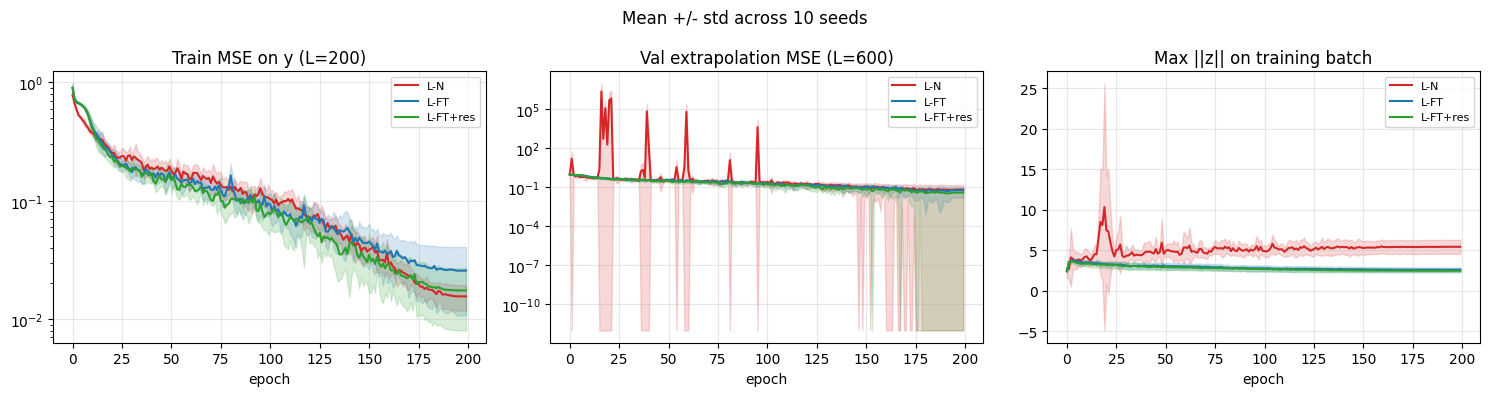

Per-model summary across seeds:
  L-N      : diverged 0/10   best-val MSE  median 1.264e-02  mean 4.521e-02  std 6.205e-02
  L-FT     : diverged 4/10   best-val MSE  median 6.970e-02  mean 1.872e-01  std 2.170e-01
  L-FT+res : diverged 2/10   best-val MSE  median 2.172e-02  mean 1.643e-01  std 2.723e-01


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for name in MODEL_NAMES:
    c = MODEL_COLOR[name]
    band(axes[0], stack_key(name, 'train'),      c, name, logy=True)
    band(axes[1], stack_key(name, 'val_extrap'), c, name, logy=True)
    band(axes[2], stack_key(name, 'zmax'),       c, name, logy=False)
axes[0].set_title(f'Train MSE on y (L={L})')
axes[1].set_title(f'Val extrapolation MSE (L={L_eval})')
axes[2].set_title('Max ||z|| on training batch')
for ax in axes:
    ax.set_xlabel('epoch'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.suptitle(f'Mean +/- std across {len(SEEDS)} seeds')
plt.tight_layout(); plt.show()

print('Per-model summary across seeds:')
for name in MODEL_NAMES:
    nd = sum(h['diverged_at'] is not None for h in histories[name])
    bv = np.array([h['best_val'] for h in histories[name]], dtype=float)
    print(f'  {name:9s}: diverged {nd}/{len(SEEDS)}   best-val MSE  '
          f'median {np.nanmedian(bv):.3e}  mean {np.nanmean(bv):.3e}  std {np.nanstd(bv):.3e}')

### 3.5 Best-val MSE distribution (headline consistency metric)

Box + per-seed strip of the best validation extrapolation MSE. This is the most direct read on
consistency: a compact box low on the (log) axis is the goal; long whiskers / high outliers mean the
model's quality depends on the seed.

/var/folders/9x/8bf0hckd1b122g3zlj_z9c1w0000gp/T/ipykernel_73916/2153190412.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=MODEL_NAMES, showfliers=False, widths=0.5)


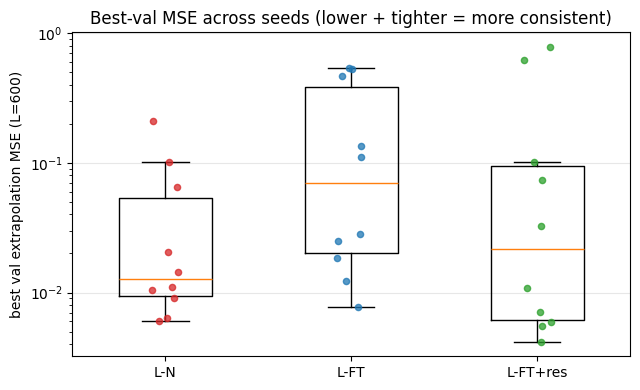

In [13]:
fig, ax = plt.subplots(figsize=(6.5, 4))
data = [np.array([h['best_val'] for h in histories[name]], dtype=float) for name in MODEL_NAMES]
ax.boxplot(data, labels=MODEL_NAMES, showfliers=False, widths=0.5)
rng = np.random.default_rng(0)
for i, (name, d) in enumerate(zip(MODEL_NAMES, data), start=1):
    d = d[np.isfinite(d)]
    x = i + (rng.random(len(d)) - 0.5) * 0.15
    ax.scatter(x, d, s=20, color=MODEL_COLOR[name], alpha=0.75, zorder=3)
ax.set_yscale('log')
ax.set_ylabel(f'best val extrapolation MSE (L={L_eval})')
ax.set_title('Best-val MSE across seeds (lower + tighter = more consistent)')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

## 4. Reconstruction on held-out long rollouts

We precompute, for every `(model, seed)`, the decoded rollout `yhat` and latent trajectory `z` on the
fixed validation set out to $L_{\mathrm{eval}}=600$ (everything past the training horizon $L=200$ is
extrapolation). These are reused by sections 4-7.

In [14]:
ROLL = {}
for name in MODEL_NAMES:
    yh = np.full((len(SEEDS), Wva_d.shape[0], L_eval + 1), np.nan, dtype=np.float32)
    zz = torch.full((len(SEEDS), Wva_d.shape[0], L_eval + 1, M_LAT), float('nan'))
    for si in range(len(SEEDS)):
        with torch.no_grad():
            yhat, zs = rollout_y(models[name][si], Wva_d, Uva_d, L_eval, h_dt)
        yh[si] = yhat.cpu().numpy()
        zz[si] = zs.cpu()
    yh = np.where(np.isfinite(yh), yh, np.nan)
    ROLL[name] = {'yhat': yh, 'z': zz}

Yva_np  = Yva.numpy()
tline_e = np.arange(L_eval + 1) * h_dt
T_train = L * h_dt
print('precomputed val rollouts for', list(ROLL.keys()))

precomputed val rollouts for ['L-N', 'L-FT', 'L-FT+res']


### 4.1 Per-seed reconstruction grid (one held-out trajectory)

One fixed validation trajectory, one panel per seed, all three models overlaid on the truth. The
dashed line marks the end of the training horizon. This is the requested all-seed small-multiples
view: it exposes seed-to-seed variability that a single overlay would hide.

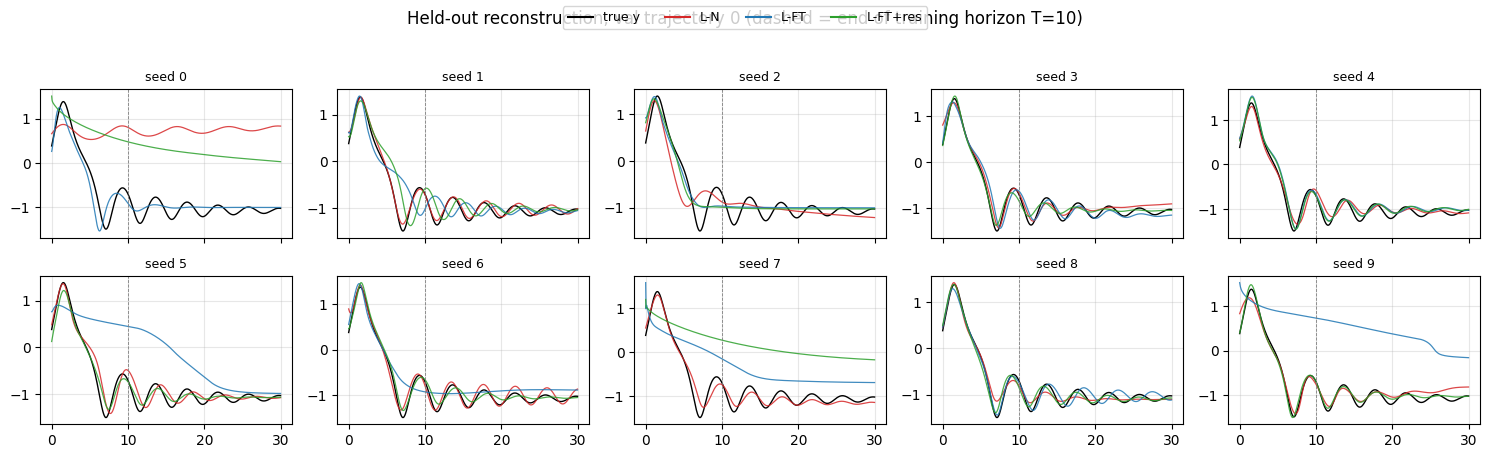

In [15]:
TRAJ = 0
fig, axes = seed_grid(len(SEEDS), ncols=5, panel=(3.0, 2.2), sharex=True)
for si, seed in enumerate(SEEDS):
    ax = axes[si]
    ax.plot(tline_e, Yva_np[TRAJ], 'k', lw=1.0)
    for name in MODEL_NAMES:
        yhat = ROLL[name]['yhat'][si, TRAJ]
        if np.all(np.isfinite(yhat)):
            ax.plot(tline_e, yhat, color=MODEL_COLOR[name], lw=0.9, alpha=0.85)
    ax.axvline(T_train, color='gray', lw=0.6, ls='--')
    ax.set_title(f'seed {seed}', fontsize=9); ax.grid(alpha=0.3)
handles = [plt.Line2D([], [], color='k', label='true y')] + \
          [plt.Line2D([], [], color=MODEL_COLOR[n], label=n) for n in MODEL_NAMES]
fig.legend(handles=handles, loc='upper center', ncol=4, fontsize=9)
fig.suptitle(f'Held-out reconstruction, val trajectory {TRAJ} '
             f'(dashed = end of training horizon T={T_train:.0f})', y=1.03)
plt.tight_layout(); plt.show()

### 4.2 Per-horizon reconstruction MSE (mean $\pm$ std over seeds)

For each model: MSE on $y$ at each horizon $t$, averaged over validation trajectories, then shown as
mean $\pm$ std across the 10 seeds.

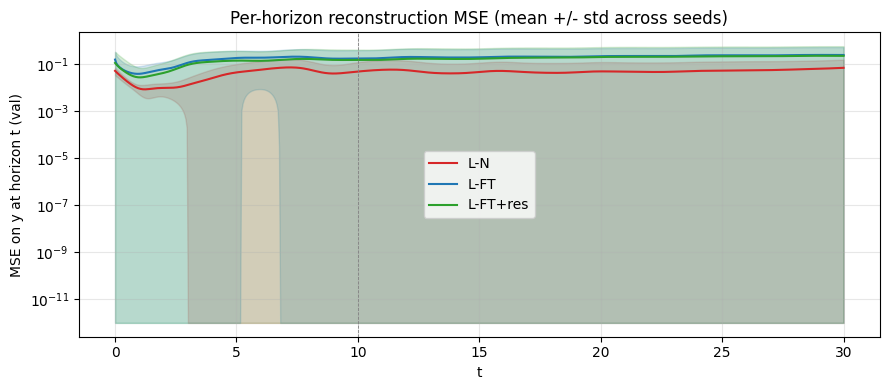

In [16]:
fig, ax = plt.subplots(figsize=(9, 4))
for name in MODEL_NAMES:
    yh = ROLL[name]['yhat']                                   # (S, B, L_eval+1)
    mse_t = np.nanmean((yh - Yva_np[None]) ** 2, axis=1)      # (S, L_eval+1)
    mean = np.nanmean(mse_t, axis=0); std = np.nanstd(mse_t, axis=0)
    c = MODEL_COLOR[name]
    ax.semilogy(tline_e, np.maximum(mean, 1e-12), color=c, lw=1.5, label=name)
    ax.fill_between(tline_e, np.maximum(mean - std, 1e-12), mean + std, color=c, alpha=0.18)
ax.axvline(T_train, color='gray', lw=0.6, ls='--')
ax.set_xlabel('t'); ax.set_ylabel('MSE on y at horizon t (val)')
ax.set_title('Per-horizon reconstruction MSE (mean +/- std across seeds)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Implicit recovery of the hidden coordinate $\dot q$

For every `(model, seed)` we fit a *linear* map from the latent state to $q$ and to the hidden
$\dot q$ on a held-out split and report $R^2$. This is a post-hoc probe of how much of the missing
coordinate the latent state encodes. We then show the **distribution of $R^2$ across seeds** per
model — both the level and the spread matter for the consistency story.

In [17]:
def linear_recovery_r2(Z, target):
    Z = np.asarray(Z); t = np.asarray(target)
    Zb = np.concatenate([Z, np.ones((Z.shape[0], 1))], axis=1)
    w, *_ = np.linalg.lstsq(Zb, t, rcond=None)
    pred = Zb @ w
    ss_res = np.sum((t - pred) ** 2)
    ss_tot = np.sum((t - t.mean()) ** 2) + 1e-12
    return 1.0 - ss_res / ss_tot, w

Q    = Xva[..., 0].numpy().reshape(-1)
Qdot = Xva[..., 1].numpy().reshape(-1)
N = Q.shape[0]
perm = np.random.default_rng(7).permutation(N)
fit_idx, eval_idx = perm[:N // 2], perm[N // 2:]

def r2_eval(Z, target):
    _, w = linear_recovery_r2(Z[fit_idx], target[fit_idx])
    pe = np.concatenate([Z[eval_idx], np.ones((len(eval_idx), 1))], 1) @ w
    ss_res = np.sum((target[eval_idx] - pe) ** 2)
    ss_tot = np.sum((target[eval_idx] - target[eval_idx].mean()) ** 2) + 1e-12
    return 1.0 - ss_res / ss_tot

R2 = {name: {'q': [], 'qdot': []} for name in MODEL_NAMES}
for name in MODEL_NAMES:
    for si in range(len(SEEDS)):
        Z = ROLL[name]['z'][si].reshape(-1, M_LAT).numpy()
        if not np.all(np.isfinite(Z)):
            R2[name]['q'].append(np.nan); R2[name]['qdot'].append(np.nan); continue
        R2[name]['q'].append(r2_eval(Z, Q))
        R2[name]['qdot'].append(r2_eval(Z, Qdot))

print('Linear recoverability (mean +/- std across seeds):')
for name in MODEL_NAMES:
    q = np.array(R2[name]['q']); qd = np.array(R2[name]['qdot'])
    print(f'  {name:9s}  R2->q  {np.nanmean(q):.3f} +/- {np.nanstd(q):.3f}    '
          f'R2->q_dot  {np.nanmean(qd):.3f} +/- {np.nanstd(qd):.3f}')

Linear recoverability (mean +/- std across seeds):
  L-N        R2->q  0.959 +/- 0.060    R2->q_dot  0.490 +/- 0.192
  L-FT       R2->q  0.823 +/- 0.203    R2->q_dot  0.346 +/- 0.251
  L-FT+res   R2->q  0.858 +/- 0.227    R2->q_dot  0.581 +/- 0.299


/var/folders/9x/8bf0hckd1b122g3zlj_z9c1w0000gp/T/ipykernel_73916/2793687009.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_fin, labels=MODEL_NAMES, showfliers=False, widths=0.5)
/var/folders/9x/8bf0hckd1b122g3zlj_z9c1w0000gp/T/ipykernel_73916/2793687009.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_fin, labels=MODEL_NAMES, showfliers=False, widths=0.5)


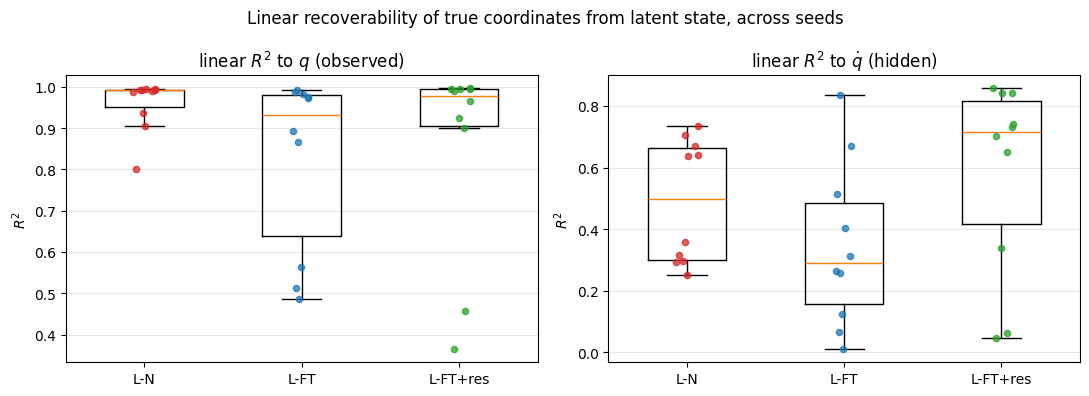

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, key, ttl in [(axes[0], 'q',    r'linear $R^2$ to $q$ (observed)'),
                     (axes[1], 'qdot', r'linear $R^2$ to $\dot q$ (hidden)')]:
    data = [np.array(R2[name][key], dtype=float) for name in MODEL_NAMES]
    data_fin = [d[np.isfinite(d)] for d in data]
    ax.boxplot(data_fin, labels=MODEL_NAMES, showfliers=False, widths=0.5)
    rng = np.random.default_rng(1)
    for i, (name, d) in enumerate(zip(MODEL_NAMES, data_fin), start=1):
        x = i + (rng.random(len(d)) - 0.5) * 0.15
        ax.scatter(x, d, s=20, color=MODEL_COLOR[name], alpha=0.75, zorder=3)
    ax.set_title(ttl); ax.set_ylabel(r'$R^2$'); ax.grid(alpha=0.3, axis='y')
fig.suptitle('Linear recoverability of true coordinates from latent state, across seeds')
plt.tight_layout(); plt.show()

## 6. Latent-space geometry

The true Duffing phase portrait (once), then for each model a 10-seed grid of latent trajectories
projected onto their leading 2 PCA components. Consistency here means the qualitative picture
(contraction toward fixed points) reproduces across seeds rather than each seed finding a different
embedding.

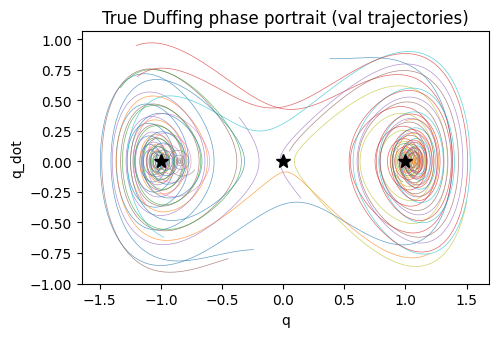

In [19]:
fig, ax = plt.subplots(figsize=(5, 5))
for i in range(min(16, Xva.shape[0])):
    ax.plot(Xva[i, :, 0].numpy(), Xva[i, :, 1].numpy(), lw=0.5, alpha=0.7)
for xe in equilibria(0.0):
    ax.plot(xe[0], xe[1], 'k*', ms=10)
ax.set_xlabel('q'); ax.set_ylabel('q_dot'); ax.set_aspect('equal')
ax.set_title('True Duffing phase portrait (val trajectories)')
plt.tight_layout(); plt.show()

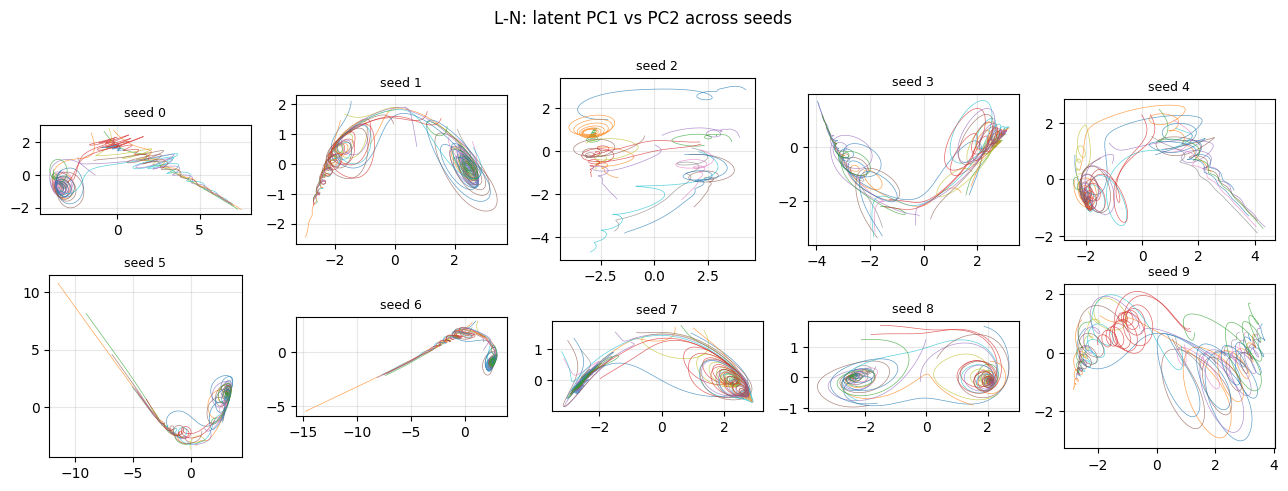

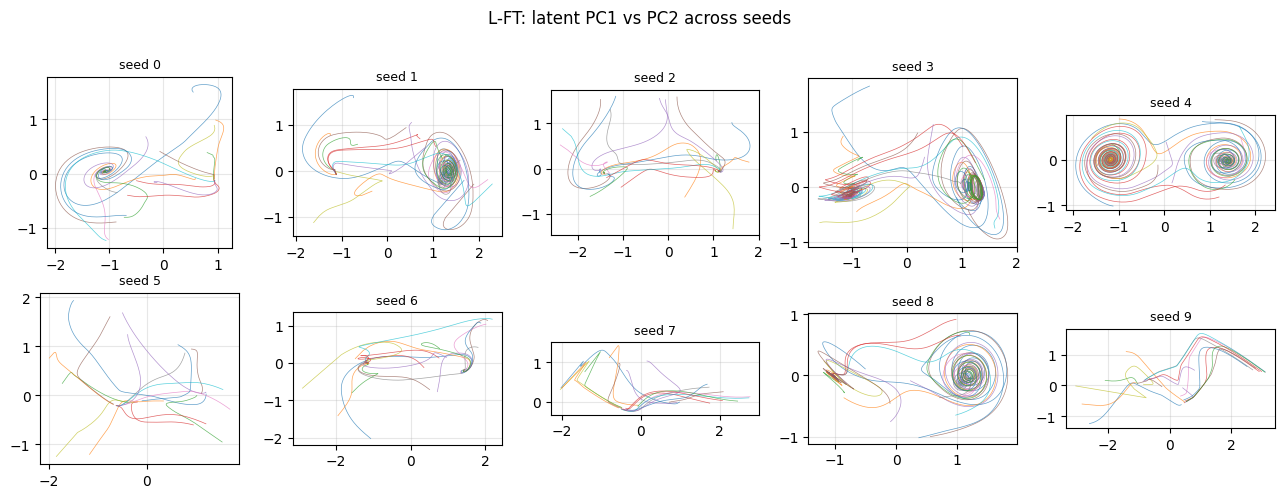

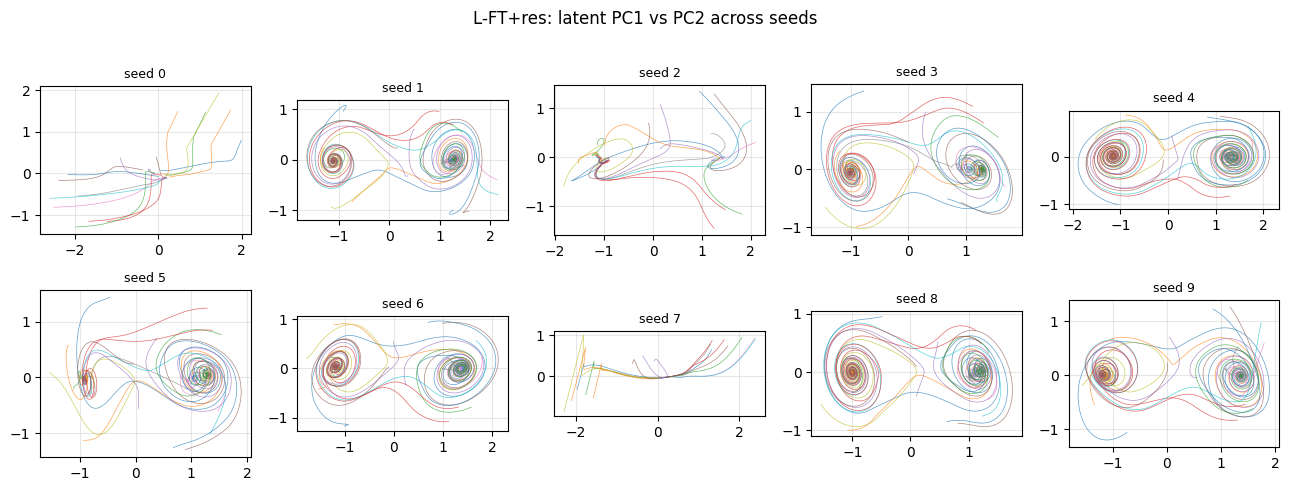

In [20]:
def pca_2d(Z):
    Zc = Z - Z.mean(axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(Zc, full_matrices=False)
    return Zc @ Vt[:2].T, Vt[:2]

for name in MODEL_NAMES:
    fig, axes = seed_grid(len(SEEDS), ncols=5, panel=(2.6, 2.4))
    for si, seed in enumerate(SEEDS):
        ax = axes[si]
        Z = ROLL[name]['z'][si].numpy()           # (B, T, m)
        Zf = Z.reshape(-1, Z.shape[-1])
        if not np.all(np.isfinite(Zf)):
            ax.set_title(f'seed {seed}: diverged', fontsize=8)
            ax.set_aspect('equal'); continue
        proj, _ = pca_2d(Zf)
        proj = proj.reshape(Z.shape[0], Z.shape[1], 2)
        for i in range(min(16, Z.shape[0])):
            ax.plot(proj[i, :, 0], proj[i, :, 1], lw=0.5, alpha=0.7)
        ax.set_title(f'seed {seed}', fontsize=9)
        ax.set_aspect('equal'); ax.grid(alpha=0.3)
    fig.suptitle(f'{name}: latent PC1 vs PC2 across seeds', y=1.01)
    plt.tight_layout(); plt.show()

# 7. Split-term diagnostics for the FTNODE variants

The structured field factorises as $\boldsymbol{F}_\theta(\boldsymbol{z},u)=\boldsymbol{A}_\theta(\boldsymbol{z})\,(\boldsymbol{z}-\boldsymbol{g}_\theta(\boldsymbol{z},u))$,
$\boldsymbol{A}_\theta=-(\boldsymbol{L}\boldsymbol{L}^\top+\sigma_{\min}\boldsymbol{I})+(\boldsymbol{M}-\boldsymbol{M}^\top)$. This split exists only for the
FTNODE models, so this section runs for **both** `L-FT` and `L-FT+res` (not `L-N`), across all seeds.
We evaluate over two state sets: the latent states visited along the held-out rollouts, and a uniform
sample of the latent box $[-R_z,R_z]^m$.

In [21]:
FT_NAMES = [c['name'] for c in MODEL_CONFIGS if c['kind'] == 'ftsuper']
dyn0 = models[FT_NAMES[0]][0].dynamics
sigma_min = float(dyn0.sigma_min)
R_g = float(dyn0.R_g)

# Shared box sample of the latent box [-R_z, R_z]^m with random u.
n_box = 4000
g_t = torch.Generator(device='cpu').manual_seed(0)
Z_box = ((2 * torch.rand(n_box, M_LAT, generator=g_t) - 1) * R_LATENT).to(device)
U_box = ((2 * torch.rand(n_box, generator=g_t) - 1) * u_range).to(device)

# True Duffing equilibrium manifold over the training u-range: roots of q^3 - q - u = 0.
u_grid = np.linspace(-u_range, u_range, 200)
eqs_per_u = [equilibria(u) for u in u_grid]
assert min(len(e) for e in eqs_per_u) == max(len(e) for e in eqs_per_u) == 3, \
    'expected 3 equilibria across the u-range (bistable window)'
branches = np.array([[e[0] for e in eqs] for eqs in eqs_per_u])   # (200, 3)

@torch.no_grad()
def eigvals_A(dyn, Z, chunk=2048):
    if Z.shape[0] == 0:
        return np.zeros((0, M_LAT), dtype=complex)
    out = []
    for i in range(0, Z.shape[0], chunk):
        A = dyn.A(Z[i:i+chunk])
        out.append(torch.linalg.eigvals(A).cpu())
    return torch.cat(out, 0).numpy()

@torch.no_grad()
def g_image(dyn, Z, U):
    return dyn.g(Z, U)

def roll_latents(name, si):
    """Finite rollout latents for (name, seed index) plus their matched controls, on device."""
    Zfull = ROLL[name]['z'][si]                    # (B, T, m)
    B, T = Zfull.shape[0], Zfull.shape[1]
    Z = Zfull.reshape(-1, M_LAT)
    U = Uva_d.detach().cpu().view(-1, 1).expand(B, T).reshape(-1)
    mask = torch.isfinite(Z).all(dim=1)
    return Z[mask].to(device), U[mask].to(device)

print('FT variants for split-term analysis:', FT_NAMES)
print(f'sigma_min = {sigma_min}, R_g = {R_g}, box samples = {n_box}')

FT variants for split-term analysis: ['L-FT', 'L-FT+res']
sigma_min = 0.1, R_g = 2.0, box samples = 4000


### 7.1 Spectrum of $\boldsymbol{A}(\boldsymbol{z})$ — contraction check across seeds

By construction $\operatorname{sym}\boldsymbol{A}\preceq-\sigma_{\min}\boldsymbol{I}$, so every eigenvalue must satisfy
$\operatorname{Re}\lambda(\boldsymbol{A})\le-\sigma_{\min}$ at every state and every seed. We confirm this numerically
(per seed) and show the complex-plane eigenvalue clouds as a per-variant 10-seed grid (blue = box,
green = rollout; dashed line = $-\sigma_{\min}$).

Contraction check  Re lambda(A) <= -sigma_min = -0.100 :
  L-FT     : max Re(lambda) over seeds = -0.1002  (all <= -sigma_min? True)
  L-FT+res : max Re(lambda) over seeds = -0.1002  (all <= -sigma_min? True)


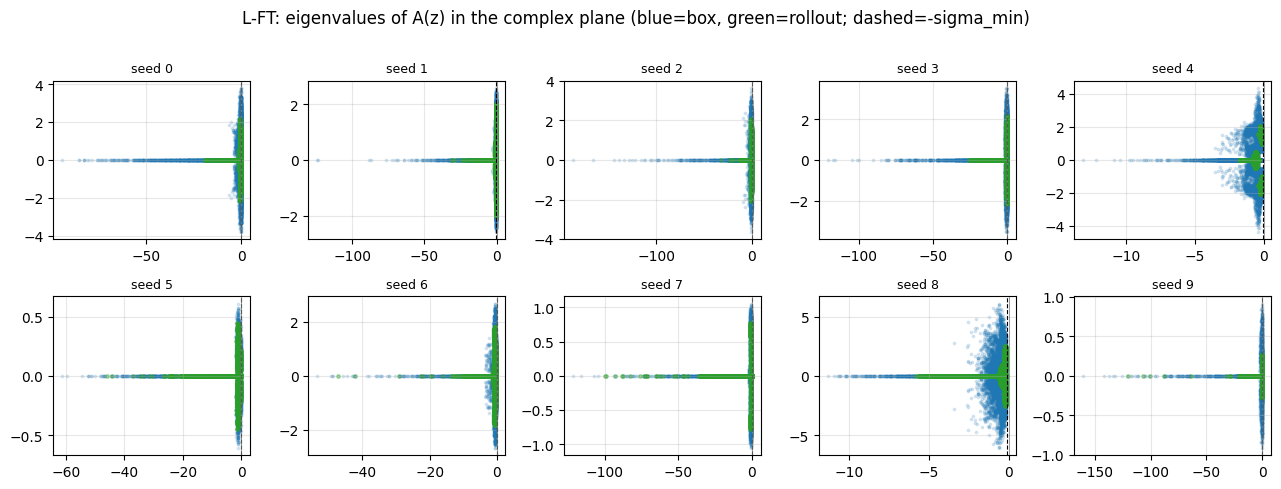

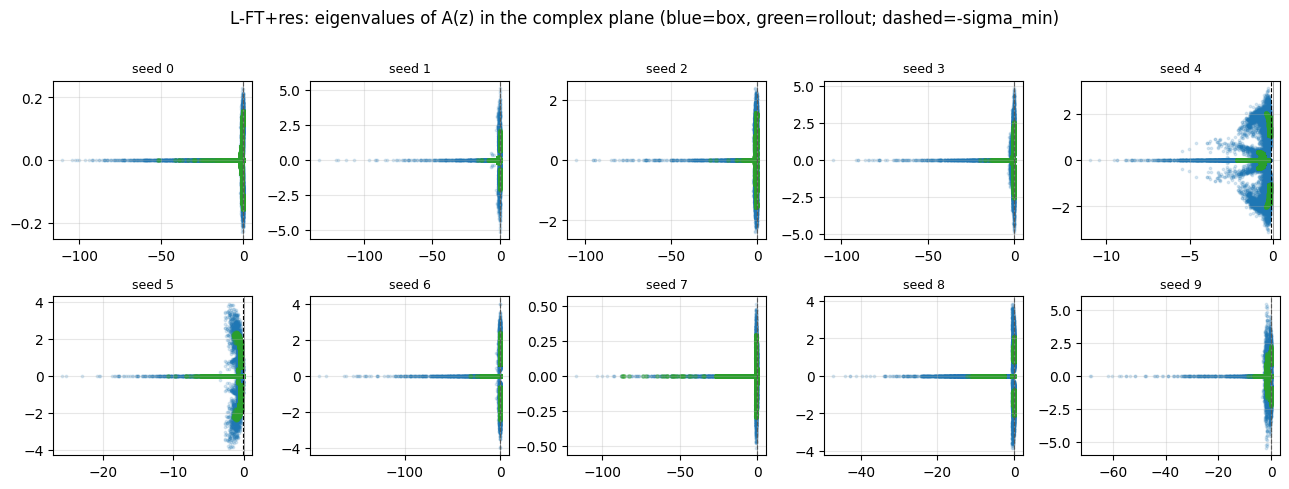

In [22]:
print('Contraction check  Re lambda(A) <= -sigma_min = %+.3f :' % (-sigma_min))
for name in FT_NAMES:
    maxres = []
    for si in range(len(SEEDS)):
        Zr, _ = roll_latents(name, si)
        if Zr.shape[0] == 0:
            continue
        ev = eigvals_A(models[name][si].dynamics, Zr)
        maxres.append(ev.real.max())
    maxres = np.array(maxres)
    ok = bool((maxres <= -sigma_min + 1e-4).all())
    print(f'  {name:9s}: max Re(lambda) over seeds = {maxres.max():+.4f}  (all <= -sigma_min? {ok})')

# Each seed panel autoscales independently (no shared x/y axes), so per-seed
# differences in the eigenvalue spread are visible rather than flattened by a
# common range. Applies to both the L-FT and L-FT+res figures.
for name in FT_NAMES:
    fig, axes = seed_grid(len(SEEDS), ncols=5, panel=(2.6, 2.4))
    for si, seed in enumerate(SEEDS):
        ax = axes[si]
        dyn = models[name][si].dynamics
        evb = eigvals_A(dyn, Z_box)
        Zr, _ = roll_latents(name, si)
        evr = eigvals_A(dyn, Zr)
        ax.scatter(evb.real.ravel(), evb.imag.ravel(), s=3, alpha=0.15, color='C0')
        if evr.shape[0]:
            ax.scatter(evr.real.ravel(), evr.imag.ravel(), s=6, alpha=0.4, color='C2')
        ax.axvline(-sigma_min, color='k', ls='--', lw=0.8)
        ax.axvline(0.0, color='gray', lw=0.5)
        ax.set_title(f'seed {seed}', fontsize=9); ax.grid(alpha=0.3)
    fig.suptitle(f'{name}: eigenvalues of A(z) in the complex plane '
                 f'(blue=box, green=rollout; dashed=-sigma_min)', y=1.01)
    plt.tight_layout(); plt.show()

### 7.2 Image of $\boldsymbol{g}$ — the learned equilibrium map across seeds

Decoding the equilibrium map, $\psi(\boldsymbol{g}(\boldsymbol{z},u))$, should track the true Duffing equilibrium
manifold (roots of $q^3-q-u=0$). We show this as a per-variant 10-seed grid against the true branches,
and print a per-variant numeric check that the latent equilibrium map stays inside the $\pm R_g$ box
across seeds.

Equilibrium-map bound check  max |g|_inf <= R_g = 2.00 :
  L-FT     : max |g|_inf over seeds = 1.234  (all <= R_g? True)
  L-FT+res : max |g|_inf over seeds = 1.169  (all <= R_g? True)


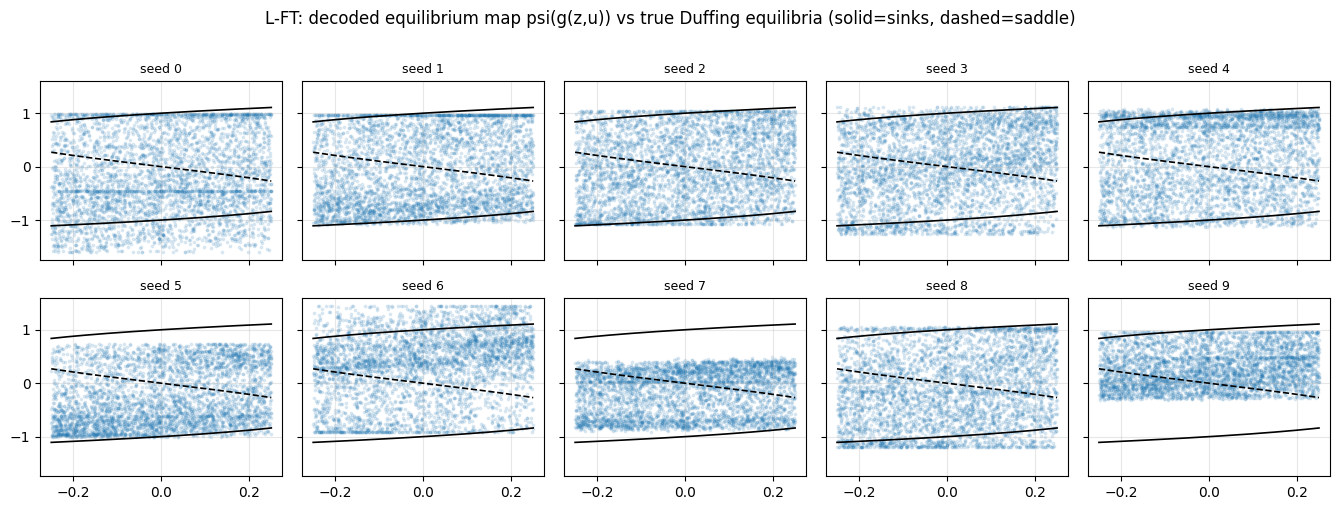

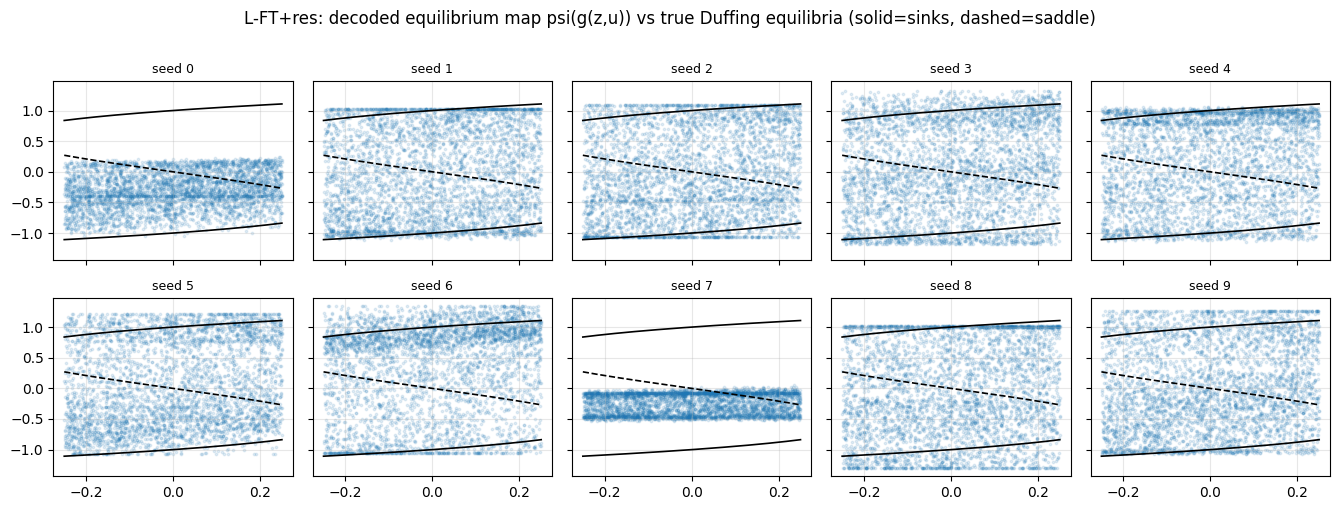

In [23]:
print('Equilibrium-map bound check  max |g|_inf <= R_g = %.2f :' % R_g)
for name in FT_NAMES:
    mx = []
    for si in range(len(SEEDS)):
        G = g_image(models[name][si].dynamics, Z_box, U_box).cpu().numpy()
        mx.append(np.abs(G).max())
    mx = np.array(mx)
    print(f'  {name:9s}: max |g|_inf over seeds = {mx.max():.3f}  (all <= R_g? {bool((mx <= R_g + 1e-4).all())})')

U_box_np = U_box.cpu().numpy()
for name in FT_NAMES:
    fig, axes = seed_grid(len(SEEDS), ncols=5, panel=(2.7, 2.5), sharex=True, sharey=True)
    for si, seed in enumerate(SEEDS):
        ax = axes[si]
        Gb = g_image(models[name][si].dynamics, Z_box, U_box)
        qg_box = models[name][si].decode(Gb).detach().cpu().numpy()
        ax.scatter(U_box_np, qg_box, s=3, alpha=0.12, color='C0')
        ax.plot(u_grid, branches[:, 0], 'k-',  lw=1.2)
        ax.plot(u_grid, branches[:, 2], 'k-',  lw=1.2)
        ax.plot(u_grid, branches[:, 1], 'k--', lw=1.2)
        ax.set_title(f'seed {seed}', fontsize=9); ax.grid(alpha=0.3)
    fig.suptitle(f'{name}: decoded equilibrium map psi(g(z,u)) vs true Duffing equilibria '
                 f'(solid=sinks, dashed=saddle)', y=1.01)
    plt.tight_layout(); plt.show()

### 7.3 Superposition-g coefficient sparsity — which anchors survive?

The point of the restrained $g$ is that redundant anchors should switch **off**. We measure
per-anchor mean activation $\overline{|\alpha_i|}$ over the validation rollouts, count the
effective (active) anchors, and report the Hoyer sparsity of the mean-$\alpha$ vector across
seeds. We also decode the learned anchors $\psi(g_i)$ against the true Duffing branches.


In [24]:
@torch.no_grad()
def anchor_activation(dyn, Z, U, chunk=4096):
    """Mean |alpha_i| over samples -> (ell,)."""
    outs = []
    for i in range(0, Z.shape[0], chunk):
        a = dyn.coeffs(Z[i:i+chunk], U[i:i+chunk])
        outs.append(a.abs().cpu())
    return torch.cat(outs, 0).mean(0).numpy() if outs else np.zeros(dyn.ell)

def hoyer_sparsity(v):
    v = np.abs(np.asarray(v, dtype=float)); n = len(v)
    l1 = v.sum(); l2 = np.sqrt((v ** 2).sum()) + 1e-12
    return (np.sqrt(n) - l1 / l2) / (np.sqrt(n) - 1.0)

ELL_ = int(models[FT_NAMES[0]][0].dynamics.ell)
ACT_THRESH = 1e-2
ACT = {}   # name -> (n_seeds, ell) mean |alpha_i|
print(f'Anchor sparsity over validation rollouts (ell={ELL_}, active if mean|alpha_i| > {ACT_THRESH}):')
for name in FT_NAMES:
    arr = np.full((len(SEEDS), ELL_), np.nan)
    for si in range(len(SEEDS)):
        Zr, Ur = roll_latents(name, si)
        if Zr.shape[0] == 0:
            continue
        arr[si] = anchor_activation(models[name][si].dynamics, Zr, Ur)
    ACT[name] = arr
    n_active = (np.nan_to_num(arr) > ACT_THRESH).sum(1)
    hs = np.array([hoyer_sparsity(np.nan_to_num(a)) for a in arr])
    print(f'  {name:10s}: mean active anchors = {np.nanmean(n_active):.1f}/{ELL_}   '
          f'Hoyer sparsity = {np.nanmean(hs):.3f} +/- {np.nanstd(hs):.3f}')


Anchor sparsity over validation rollouts (ell=8, active if mean|alpha_i| > 0.01):
  L-FT      : mean active anchors = 5.9/8   Hoyer sparsity = 0.443 +/- 0.110
  L-FT+res  : mean active anchors = 6.1/8   Hoyer sparsity = 0.492 +/- 0.081


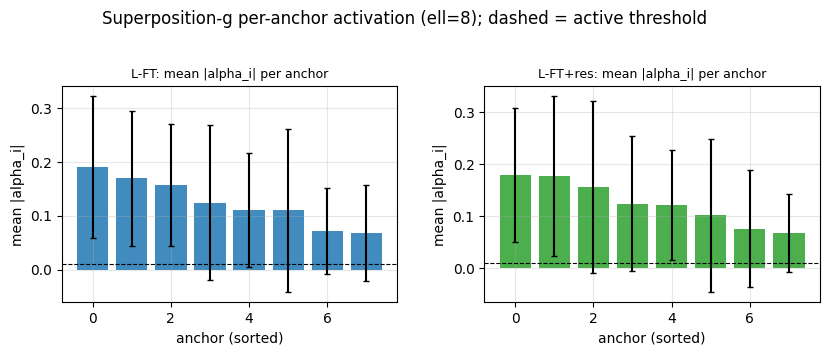

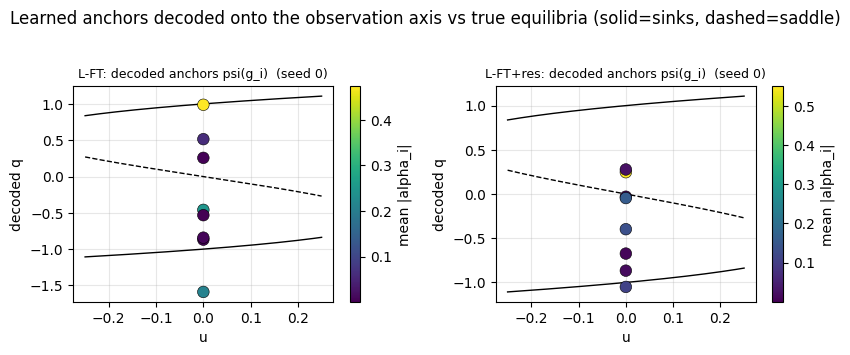

In [25]:
# Per-anchor mean activation (sorted), mean +/- std over seeds: vanishing bars = pruned anchors.
fig, axes = plt.subplots(1, len(FT_NAMES), figsize=(4.3 * len(FT_NAMES), 3.4), squeeze=False)
for j, name in enumerate(FT_NAMES):
    ax = axes[0][j]
    arr = ACT[name]
    mean = np.nanmean(arr, 0); std = np.nanstd(arr, 0)
    order = np.argsort(-mean)
    ax.bar(np.arange(ELL_), mean[order], yerr=std[order],
           color=MODEL_COLOR.get(name, 'C0'), alpha=0.85, capsize=2)
    ax.axhline(ACT_THRESH, color='k', ls='--', lw=0.8)
    ax.set_title(f'{name}: mean |alpha_i| per anchor', fontsize=9)
    ax.set_xlabel('anchor (sorted)'); ax.set_ylabel('mean |alpha_i|'); ax.grid(alpha=0.3)
fig.suptitle(f'Superposition-g per-anchor activation (ell={ELL_}); dashed = active threshold', y=1.03)
plt.tight_layout(); plt.show()

# Decoded anchors psi(g_i) vs true Duffing branches (seed 0), coloured by activation.
fig, axes = plt.subplots(1, len(FT_NAMES), figsize=(4.3 * len(FT_NAMES), 3.4), squeeze=False)
for j, name in enumerate(FT_NAMES):
    ax = axes[0][j]
    dyn = models[name][0].dynamics
    anch = dyn.g_mod.anchors().detach()                       # (ell, m)
    q_anch = models[name][0].decode(anch).detach().cpu().numpy().ravel()
    act0 = np.nan_to_num(ACT[name][0])
    ax.plot(u_grid, branches[:, 0], 'k-', lw=1.0)
    ax.plot(u_grid, branches[:, 2], 'k-', lw=1.0)
    ax.plot(u_grid, branches[:, 1], 'k--', lw=1.0)
    sc = ax.scatter(np.zeros_like(q_anch), q_anch, c=act0, cmap='viridis', s=70, zorder=3,
                    edgecolor='k', linewidth=0.4)
    plt.colorbar(sc, ax=ax, label='mean |alpha_i|')
    ax.set_title(f'{name}: decoded anchors psi(g_i)  (seed 0)', fontsize=9)
    ax.set_xlabel('u'); ax.set_ylabel('decoded q'); ax.grid(alpha=0.3)
fig.suptitle('Learned anchors decoded onto the observation axis vs true equilibria '
             '(solid=sinks, dashed=saddle)', y=1.03)
plt.tight_layout(); plt.show()


## 8. How to read this notebook

- **§3.4 / §3.5** are the headline consistency views: tight, low bands/boxes = a model that trains
  reproducibly across seeds. Watch the L-N divergence count and the width of its best-val box versus
  the two FTNODE variants.
- **§4.2** shows whether reconstruction quality (and its seed-spread) degrades gracefully past the
  training horizon $T=10$.
- **§5** asks whether the *hidden* coordinate $\dot q$ is recovered consistently — the FTNODE prior is
  expected to help both the level and the seed-to-seed stability of $R^2(\dot q)$.
- **§7** confirms the structural guarantees hold at *every* seed (contraction bound, bounded
  equilibrium map) and shows how consistently each FTNODE variant identifies the true equilibrium
  manifold; comparing `L-FT` vs `L-FT+res` isolates the effect of the residual regularization on
  reproducibility.